# Breast Ultrasound Image Classification: CNN from Scratch vs Transfer Learning

**Foundations of Deep Learning (2025/2026) — Università degli Studi di Milano-Bicocca**

## Context

Breast cancer screening increasingly relies on ultrasound imaging as a fast,
radiation-free complement to mammography, particularly for younger patients
and dense breast tissue. Automating the initial triage of ultrasound images
into clinically meaningful categories — **benign**, **malignant**, **normal**
— could support radiologists in prioritising cases, but it is a genuinely
hard problem: ultrasound images are noisy, operator-dependent, and public
annotated datasets are small.

The **BUSI** dataset (Al-Dhabyani et al., 2020) reflects this real-world
setting: 780 images collected from 600 female patients aged 25–75, acquired
in 2018, categorised into the three classes above.

## Objective

This project asks a specific question: **can a CNN trained from scratch
reliably classify breast ultrasound images into these three classes, and
what are the practical limits of this approach on a small, imbalanced
medical imaging dataset?**

The CNN-from-scratch model is the primary contribution of this work.
Transfer learning is used only as a comparative reference point, to
quantify — not to substitute — the ceiling reached by the from-scratch
approach.

The clinical stakes motivate the choice of metrics: misclassifying a
malignant mass as benign (false negative) delays treatment, while
misclassifying normal tissue as malignant (false positive) leads to
unnecessary interventions. Both error types have direct consequences for
patients, so per-class F1 and confusion matrices matter as much as overall
accuracy.

## Notebook structure

The notebook is organised into five blocks:

1. **Data pipeline** — loading BUSI from Drive, stratified 70/15/15 split,
   exploratory class-distribution analysis, class weight computation.
2. **CNN from scratch** — baseline architecture iterated across five
   versions (augmentation strategies, regularisation, oversampling).
3. **Transfer learning** — four frozen ImageNet backbones evaluated as a
   comparative ceiling reference.
4. **Final evaluation** — best scratch model vs. best transfer-learning
   model on the held-out test set.
5. **Conclusions** — clinical framing, results discussion, limitations,
   future work.

All random seeds are fixed (`random_state=0` for splitting,
`tf.random.set_seed(0)` for training) for reproducibility.

# **DATASET SETUP AND DATA PIPELINE**

In [ ]:
import tensorflow as tf
from tensorflow import keras

from google.colab import drive

from matplotlib import pyplot as plt
import numpy as np
import random as python_random
from sklearn.utils.class_weight import compute_class_weight
import os
import shutil

np.random.seed(0)
python_random.seed(0)
tf.random.set_seed(0)

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#train/val/test

from sklearn.model_selection import train_test_split

source_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/Dataset_BUSI_with_GT/'
dest_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/BUSI_split/'
splits = {'train': 0.7, 'val': 0.15, 'test': 0.15}
class_names = ['benign', 'malignant', 'normal']

if not os.path.exists(dest_path):
  for cls in class_names:
      cls_path = os.path.join(source_path, cls)
      images = sorted([f for f in os.listdir(cls_path) if '_mask' not in f])

      train, temp = train_test_split(images, test_size=(1 - splits['train']), random_state=0)
      val, test = train_test_split(temp, test_size=0.5, random_state=0)

      for split, files in zip(['train', 'val', 'test'], [train, val, test]):
          dest = os.path.join(dest_path, split, cls)
          os.makedirs(dest, exist_ok=True)
          for f in files:
              shutil.copy(os.path.join(cls_path, f), os.path.join(dest, f))

In [ ]:
train_dataset = keras.utils.image_dataset_from_directory(
    dest_path + 'train',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=True,
    seed=1
)

val_dataset = keras.utils.image_dataset_from_directory(
    dest_path + 'val',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False,
    seed=1
)

test_dataset = keras.utils.image_dataset_from_directory(
    dest_path + 'test',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False,
    seed=1
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 544 files belonging to 3 classes.
Found 118 files belonging to 3 classes.
Found 118 files belonging to 3 classes.
Classes: ['benign', 'malignant', 'normal']


Training set class distribution:
  benign: 305 images
  malignant: 146 images
  normal: 93 images


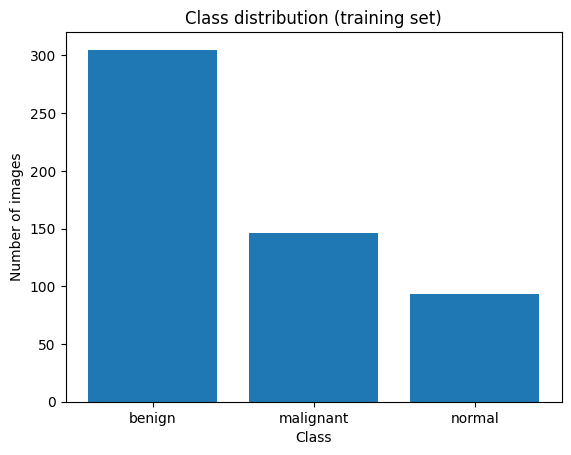

In [ ]:
#class imbalance detection

class_counts = np.zeros(len(class_names), dtype=int)
for _, labels in train_dataset:
    class_counts += np.sum(labels.numpy(), axis=0).astype(int)

print("Training set class distribution:")
for name, count in zip(class_names, class_counts):
    print(f"  {name}: {count} images")

plt.bar(class_names, class_counts)
plt.title('Class distribution (training set)')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.show()

In [ ]:
#class weights

y_train = []

for _, labels in train_dataset:
    y_train.extend(np.argmax(labels.numpy(), axis=1))
y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train)

class_weight_dict = dict(enumerate(class_weights))

print("Computed class weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weight_dict[i]:.4f}")

Computed class weights:
  benign: 0.5945
  malignant: 1.2420
  normal: 1.9498


## **Block 2: Baseline CNN and Class Imbalance Handling**

In [ ]:
# v definition
num_classes = 3

inputs = keras.Input(shape=(224, 224, 3))
x = inputs

#augmentation layers active only during training
x = keras.layers.RandomFlip(mode='horizontal')(x)
x = keras.layers.RandomRotation(factor=0.05)(x)
x = keras.layers.RandomContrast(factor=0.2)(x)
x = keras.layers.RandomBrightness(factor=0.2)(x)

#block 1
x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

#block 2
x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

#block 3
x = keras.layers.Conv2D(128, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalAveragePooling2D()(x)

#dense layers
x = keras.layers.Dense(64, activation='relu')(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

net = keras.Model(inputs, outputs)
net.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
net.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy'])

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/cnn_scratch_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1)

In [ ]:
# training v
import json

checkpoint_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/cnn_scratch_best.keras'
history_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/history.json'

if os.path.exists(checkpoint_path):
    print("Checkpoint found, loading existing model...")
    net = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    print("No checkpoint found, training from scratch...")
    history = net.fit(
        train_dataset,
        epochs=100,
        validation_data=val_dataset,
        class_weight=class_weight_dict,
        callbacks=[callback, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)

Checkpoint found, loading existing model...


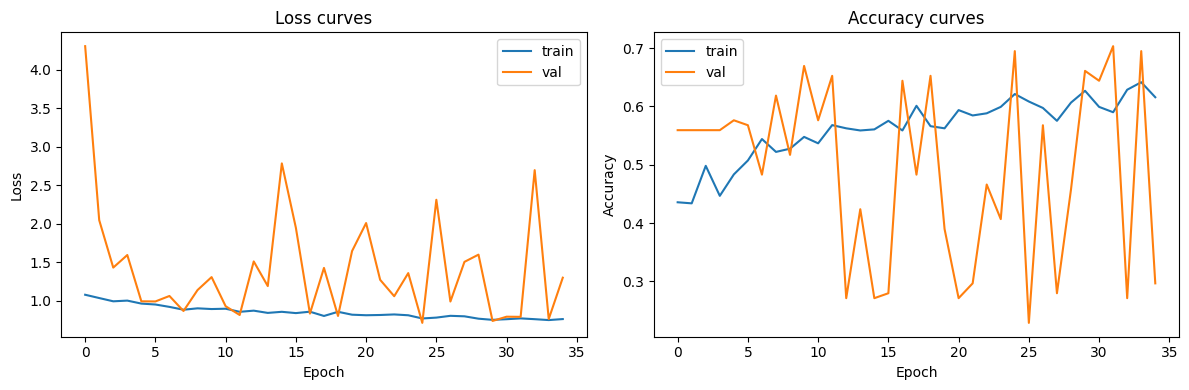

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])
plt.title('Accuracy curves')

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 50s 12s/step
              precision    recall  f1-score   support

      benign       0.69      0.92      0.79        66
   malignant       0.73      0.59      0.66        32
      normal       0.67      0.10      0.17        20

    accuracy                           0.69       118
   macro avg       0.69      0.54      0.54       118
weighted avg       0.69      0.69      0.65       118



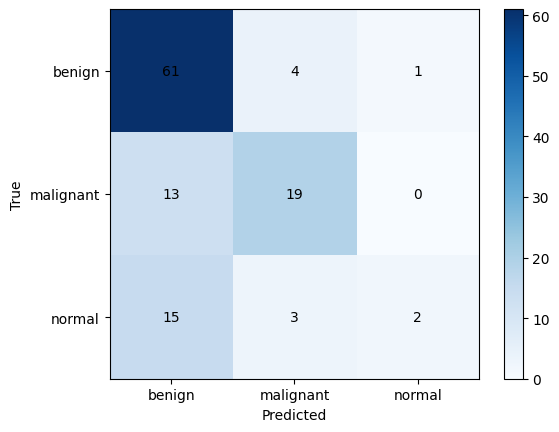

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_val_pred_probs = net.predict(val_dataset)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

y_val_true = np.concatenate([y for _, y in val_dataset], axis=0)
y_val_true = np.argmax(y_val_true, axis=1)

print(classification_report(y_val_true, y_val_pred, target_names=class_names))

cm = confusion_matrix(y_val_true, y_val_pred)
plt.imshow(cm, cmap=plt.cm.Blues)
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.colorbar()
plt.show()

# **V2 Strategy**


In [ ]:
# v2 definition
num_classes = 3

inputs = keras.Input(shape=(224, 224, 3))
x = inputs

#augmentation layers increased from v1
x = keras.layers.RandomFlip(mode='horizontal')(x)
x = keras.layers.RandomRotation(factor=0.08)(x)      # was 0.05
x = keras.layers.RandomContrast(factor=0.3)(x)        # was 0.2
x = keras.layers.RandomBrightness(factor=0.3)(x)      # was 0.2

#block 1
x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

#block 2
x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

#block 3
x = keras.layers.Conv2D(128, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)

#global average pooling
x = keras.layers.GlobalAveragePooling2D()(x)

#classification head with dropout
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

net = keras.Model(inputs, outputs)
net.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_1             │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
net.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)


callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
os.makedirs('/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch', exist_ok=True)

checkpoint_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/cnn_scratch_v2_best.keras'
history_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/history_v2.json'

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
import json

if os.path.exists(checkpoint_path):
    print("Checkpoint found, loading existing model...")
    net = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    print("No checkpoint found, training from scratch...")
    history = net.fit(
        train_dataset,
        epochs=100,
        validation_data=val_dataset,
        class_weight=class_weight_dict,
        callbacks=[callback, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)


Checkpoint found, loading existing model...


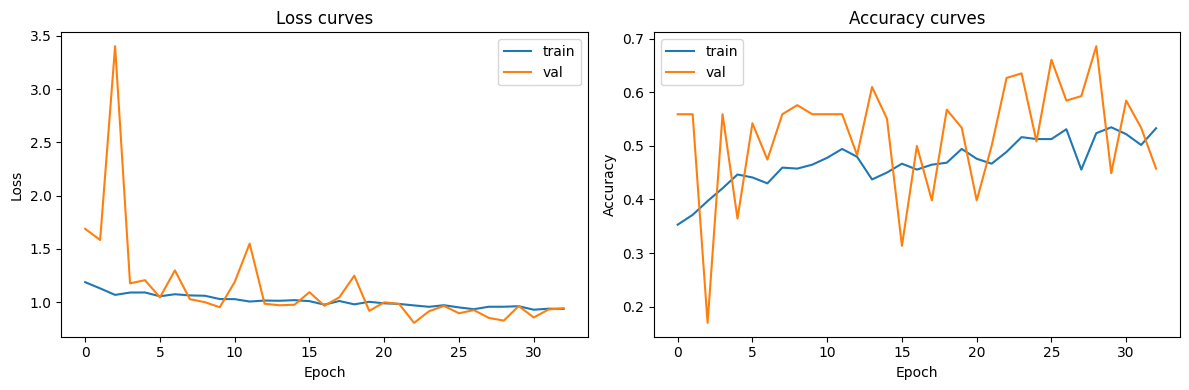

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])
plt.title('Accuracy curves')

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 995ms/step
              precision    recall  f1-score   support

      benign       0.64      0.88      0.74        66
   malignant       0.64      0.44      0.52        32
      normal       0.40      0.10      0.16        20

    accuracy                           0.63       118
   macro avg       0.56      0.47      0.47       118
weighted avg       0.60      0.63      0.58       118



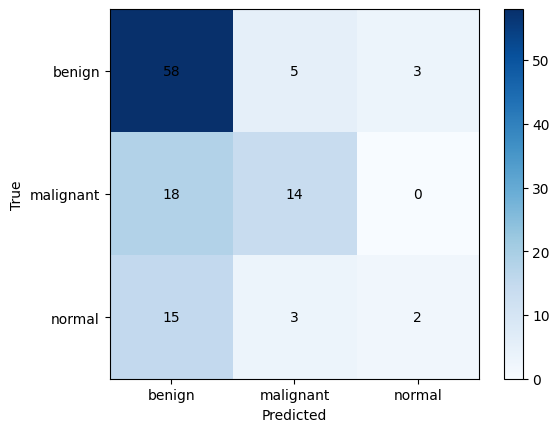

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_val_pred_probs = net.predict(val_dataset)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

y_val_true = np.concatenate([y for _, y in val_dataset], axis=0)
y_val_true = np.argmax(y_val_true, axis=1)

print(classification_report(y_val_true, y_val_pred, target_names=class_names))

cm = confusion_matrix(y_val_true, y_val_pred)
plt.imshow(cm, cmap=plt.cm.Blues)
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.colorbar()
plt.show()

# **V3 strategy**

In [ ]:
oversample_busi_split_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/oversample_BUSI_split/'
busi_split_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/BUSI_split/'

# crea struttura cartelle
for split in splits:
    for cls in class_names:
        os.makedirs(os.path.join(oversample_busi_split_path, split, cls), exist_ok=True)

# copia tutto da BUSI_split (val, test e train originali)
for split in splits:
    for cls in class_names:
        src_dir = os.path.join(busi_split_path, split, cls)
        dst_dir = os.path.join(oversample_busi_split_path, split, cls)
        for f in os.listdir(src_dir):
            src = os.path.join(src_dir, f)
            dst = os.path.join(dst_dir, f)
            if not os.path.exists(dst):
                shutil.copy(src, dst)

print("Copia base completata.")

# oversampling solo su train
factors = {'benign': 1, 'malignant': 2, 'normal': 3}
train_path = os.path.join(oversample_busi_split_path, 'train/')

for cls, factor in factors.items():
    cls_path = os.path.join(train_path, cls)
    files = [f for f in os.listdir(cls_path) if not f.startswith('copy')]

    for i in range(1, factor):
        for f in files:
            src = os.path.join(cls_path, f)
            dst = os.path.join(cls_path, f'copy{i}_{f}')
            if not os.path.exists(dst):
                shutil.copy(src, dst)

for cls in class_names:
    n = len(os.listdir(os.path.join(train_path, cls)))
    print(f"{cls}: {n}")

Copia base completata.
benign: 305
malignant: 292
normal: 279


In [ ]:
train_dataset = keras.utils.image_dataset_from_directory(
    oversample_busi_split_path + 'train',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=True,
    seed=1
)

Found 876 files belonging to 3 classes.


In [ ]:
# Model v3 — oversampling, no class weights

num_classes = 3

inputs = keras.Input(shape=(224, 224, 3))
x = inputs

x = keras.layers.RandomFlip(mode='horizontal')(x)
x = keras.layers.RandomRotation(factor=0.08)(x)
x = keras.layers.RandomContrast(factor=0.3)(x)
x = keras.layers.RandomBrightness(factor=0.3)(x)

x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(128, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

net = keras.Model(inputs, outputs)
net.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_2             │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
net.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True

)

checkpoint_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/cnn_scratch_v3_best.keras'
history_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/history_v3.json'

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
import json

if os.path.exists(checkpoint_path):
    print("Checkpoint found, loading existing model...")
    net = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    print("No checkpoint found, training from scratch...")
    history = net.fit(
        train_dataset,
        epochs=100,
        validation_data=val_dataset,
        callbacks=[callback, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)

Checkpoint found, loading existing model...


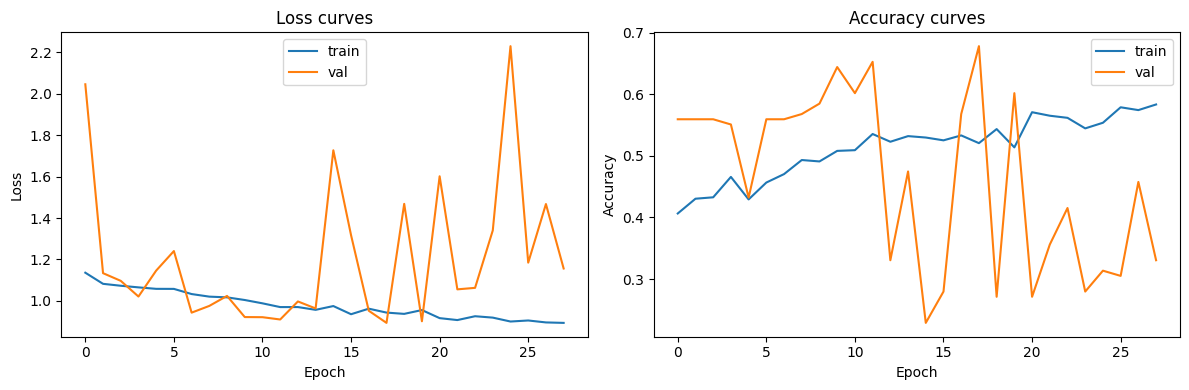

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])
plt.title('Accuracy curves')

plt.tight_layout()
plt.show()

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 813ms/step
              precision    recall  f1-score   support

      benign       0.68      0.89      0.77        66
   malignant       0.68      0.66      0.67        32
      normal       0.00      0.00      0.00        20

    accuracy                           0.68       118
   macro avg       0.45      0.52      0.48       118
weighted avg       0.56      0.68      0.61       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


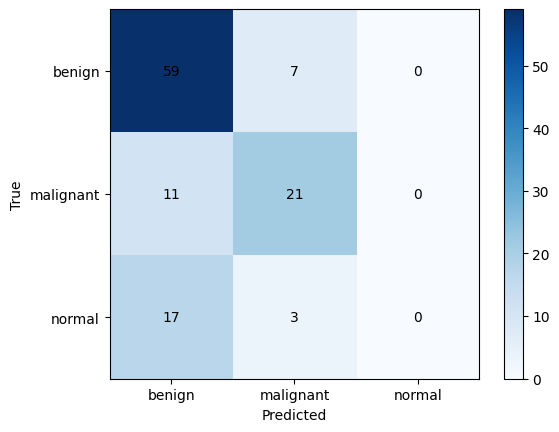

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_val_pred_probs = net.predict(val_dataset)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

y_val_true = np.concatenate([y for _, y in val_dataset], axis=0)
y_val_true = np.argmax(y_val_true, axis=1)

print(classification_report(y_val_true, y_val_pred, target_names=class_names))

cm = confusion_matrix(y_val_true, y_val_pred)
plt.imshow(cm, cmap=plt.cm.Blues)
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.colorbar()
plt.show()

# **V4 strategy**

In [ ]:
print(dest_path)

/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/BUSI_split/


In [ ]:
train_path = dest_path + 'train/'

for cls in class_names:
    cls_path = os.path.join(train_path, cls)
    for f in os.listdir(cls_path):
        if f.startswith('copy') or f.startswith('aug'):
            os.remove(os.path.join(cls_path, f))

for cls in class_names:
    n = len(os.listdir(os.path.join(train_path, cls)))
    print(f"{cls}: {n}")

benign: 305
malignant: 146
normal: 93


In [ ]:
# Augmentation offline — genera aug_BUSI_split con copie fisiche trasformate

from time import time

aug_busi_split_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/aug_BUSI_split/'

# copia struttura da BUSI_split (val e test identici, train solo originali)
for split in ['train', 'val', 'test']:
    for cls in class_names:
        os.makedirs(os.path.join(aug_busi_split_path, split, cls), exist_ok=True)
        src_dir = os.path.join(dest_path, split, cls)
        dst_dir = os.path.join(aug_busi_split_path, split, cls)
        for f in os.listdir(src_dir):
            dst = os.path.join(dst_dir, f)
            if not os.path.exists(dst):
                shutil.copy(os.path.join(src_dir, f), dst)

print("Struttura copiata da BUSI_split.")

augment_layer = keras.Sequential([
    keras.layers.RandomFlip(mode='horizontal'),
    keras.layers.RandomRotation(factor=0.08),
    keras.layers.RandomContrast(factor=0.3),
    keras.layers.RandomBrightness(factor=0.3),
])

n_copies = 3
aug_train_path = aug_busi_split_path + 'train/'

t0 = time()

for cls in class_names:
    cls_path = os.path.join(aug_train_path, cls)
    files = [f for f in os.listdir(cls_path) if not f.startswith('aug')]

    t_cls = time()
    for f in files:
        img = keras.utils.load_img(os.path.join(cls_path, f))
        img_array = keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, 0)

        for i in range(n_copies):
            dest_file = os.path.join(cls_path, f'aug{i}_{f}')
            if not os.path.exists(dest_file):
                augmented = augment_layer(img_array, training=True)
                augmented_img = keras.utils.array_to_img(augmented[0])
                augmented_img.save(dest_file)

    print(f"{cls} done in {time() - t_cls:.1f}s")

print(f"Total time: {time() - t0:.1f}s")

for cls in class_names:
    n = len(os.listdir(os.path.join(aug_train_path, cls)))
    print(f"{cls}: {n}")

Struttura copiata da BUSI_split.
benign done in 40.6s
malignant done in 21.5s
normal done in 8.9s
Total time: 71.1s
benign: 1220
malignant: 584
normal: 372


In [ ]:
#TRAIN DATASET = AUG DATASET
train_dataset = keras.utils.image_dataset_from_directory(
    aug_busi_split_path + 'train',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=True,
    seed=1
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 2176 files belonging to 3 classes.
Classes: ['benign', 'malignant', 'normal']


In [ ]:
# re-computing weights
y_train = []
for _, labels in train_dataset:
    y_train.extend(np.argmax(labels.numpy(), axis=1))
y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

for i, name in enumerate(class_names):
    print(f"{name}: {class_weight_dict[i]:.4f}")

benign: 0.5945
malignant: 1.2420
normal: 1.9498


In [ ]:
# model v4

num_classes = 3

inputs = keras.Input(shape=(224, 224, 3))
x = inputs

x = keras.layers.RandomFlip(mode='horizontal')(x)
x = keras.layers.RandomRotation(factor=0.05)(x)
x = keras.layers.RandomContrast(factor=0.2)(x)
x = keras.layers.RandomBrightness(factor=0.2)(x)

x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(128, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

net = keras.Model(inputs, outputs)
net.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_4               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_4             │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
net.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/cnn_scratch_v4_best.keras'
history_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/history_v4.json'

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
import json

if os.path.exists(checkpoint_path):
    print("Checkpoint found, loading existing model...")
    net = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    print("No checkpoint found, training from scratch...")
    history = net.fit(
        train_dataset,
        epochs=100,
        validation_data=val_dataset,
        class_weight=class_weight_dict,
        callbacks=[callback, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)

Checkpoint found, loading existing model...


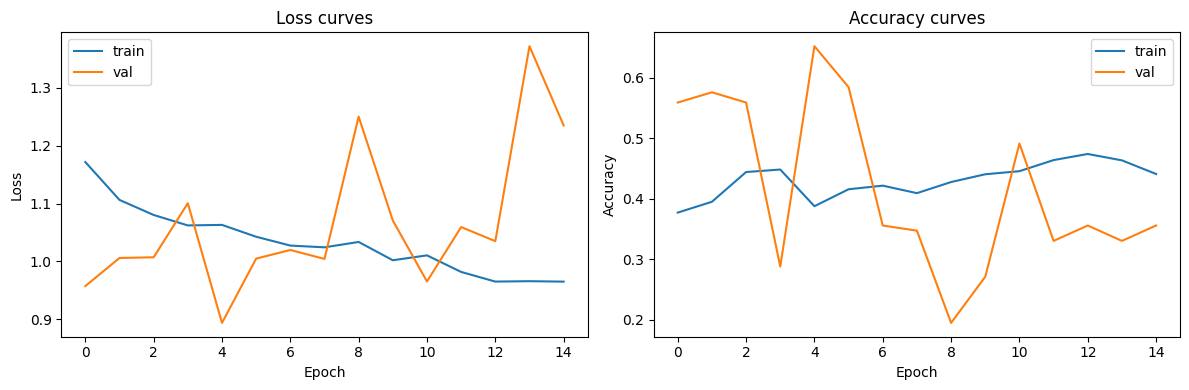

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])
plt.title('Accuracy curves')

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 701ms/step
              precision    recall  f1-score   support

      benign       0.66      0.89      0.76        66
   malignant       0.62      0.56      0.59        32
      normal       0.00      0.00      0.00        20

    accuracy                           0.65       118
   macro avg       0.43      0.49      0.45       118
weighted avg       0.54      0.65      0.59       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


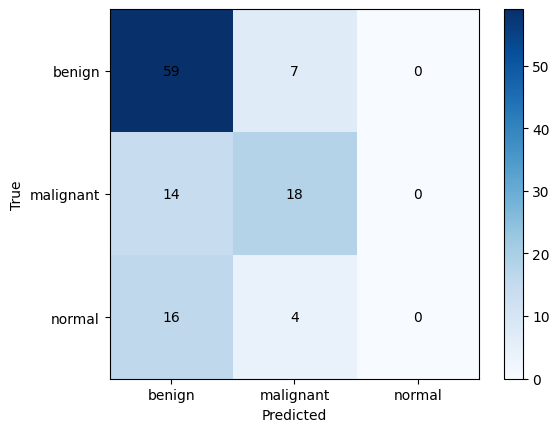

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_val_pred_probs = net.predict(val_dataset)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

y_val_true = np.concatenate([y for _, y in val_dataset], axis=0)
y_val_true = np.argmax(y_val_true, axis=1)

print(classification_report(y_val_true, y_val_pred, target_names=class_names))

cm = confusion_matrix(y_val_true, y_val_pred)
plt.imshow(cm, cmap=plt.cm.Blues)
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.colorbar()
plt.show()

# **V5 strategy**

In [ ]:
#model v6 = offline aug + class_weight + no dropout

num_classes = 3

inputs = keras.Input(shape=(224, 224, 3))
x = inputs

x = keras.layers.RandomFlip(mode='horizontal')(x)
x = keras.layers.RandomRotation(factor=0.08)(x)
x = keras.layers.RandomContrast(factor=0.3)(x)
x = keras.layers.RandomBrightness(factor=0.3)(x)

x = keras.layers.Conv2D(32, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(64, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)
x = keras.layers.MaxPooling2D(3, strides=3, padding='same')(x)

x = keras.layers.Conv2D(128, 3, padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation('relu')(x)

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dense(64, activation='relu')(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

net = keras.Model(inputs, outputs)
net.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_6 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_6               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_6               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_6             │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
net.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/cnn_scratch_v5_best.keras'
history_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/history_v5.json'

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
#TRAIN DATASET = AUG DATASET
train_dataset = keras.utils.image_dataset_from_directory(
    aug_busi_split_path + 'train',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=True,
    seed=1
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 2176 files belonging to 3 classes.
Classes: ['benign', 'malignant', 'normal']


In [ ]:
if os.path.exists(checkpoint_path):
    print("Checkpoint found, loading existing model...")
    net = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    print("No checkpoint found, training from scratch...")
    history = net.fit(
        train_dataset,
        epochs=100,
        validation_data=val_dataset,
        class_weight=class_weight_dict,
        callbacks=[callback, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)

Checkpoint found, loading existing model...


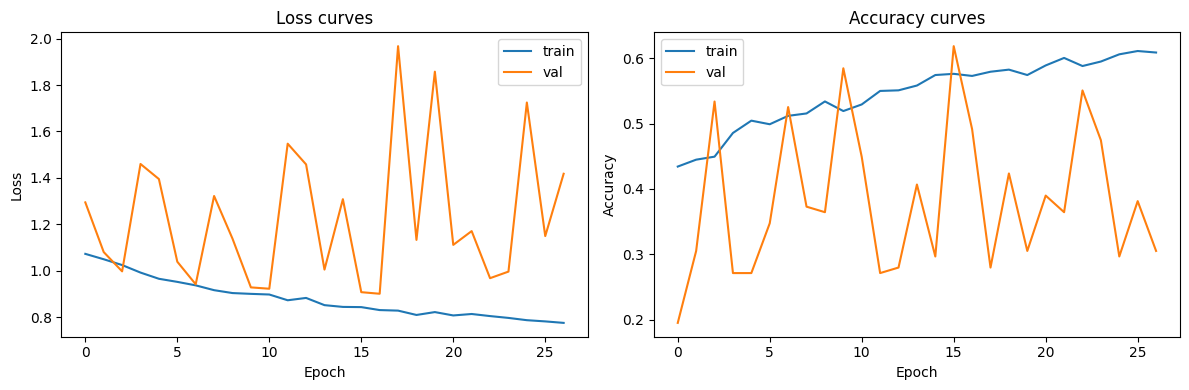

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.title('Loss curves')

plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])
plt.title('Accuracy curves')

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
              precision    recall  f1-score   support

      benign       0.83      0.30      0.44        66
   malignant       0.39      0.91      0.54        32
      normal       0.47      0.45      0.46        20

    accuracy                           0.49       118
   macro avg       0.56      0.55      0.48       118
weighted avg       0.65      0.49      0.47       118



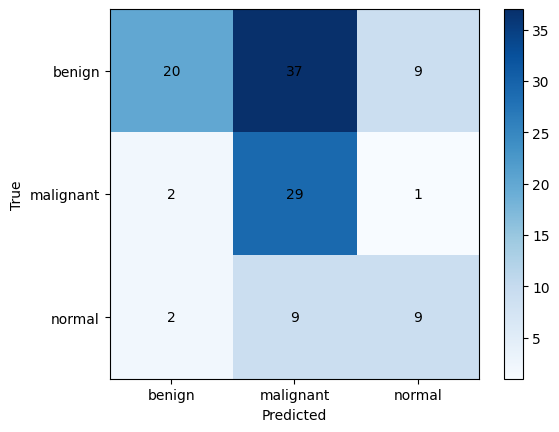

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_val_pred_probs = net.predict(val_dataset)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

y_val_true = np.concatenate([y for _, y in val_dataset], axis=0)
y_val_true = np.argmax(y_val_true, axis=1)

print(classification_report(y_val_true, y_val_pred, target_names=class_names))

cm = confusion_matrix(y_val_true, y_val_pred)
plt.imshow(cm, cmap=plt.cm.Blues)
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.colorbar()
plt.show()

In [ ]:
import json
import os
import numpy as np
from sklearn.metrics import accuracy_score

models_dir = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/'

checkpoints = {
    'v1 (inline aug, no dropout, class_w)':       'cnn_scratch_best.keras',
    'v2 (inline aug↑, dropout 0.3, class_w)':     'cnn_scratch_v2_best.keras',
    'v3 (oversampling, dropout 0.3, no class_w)': 'cnn_scratch_v3_best.keras',
    'v4 (offline aug, dropout 0.5, class_w)':     'cnn_scratch_v4_best.keras',
    'v5 (offline aug, no dropout, class_w)':      'cnn_scratch_v5_best.keras',
}

y_val_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_dataset])

print(f"{'Modello':<45} {'Val accuracy (118)':>18}")
print("-" * 65)

for label, fname in checkpoints.items():
    path = os.path.join(models_dir, fname)
    if not os.path.exists(path):
        print(f"{label:<45} {'(non trovato)':>18}")
        continue
    model = keras.models.load_model(path)
    y_pred = np.argmax(model.predict(val_dataset, verbose=0), axis=1)
    acc = accuracy_score(y_val_true, y_pred)
    print(f"{label:<45} {acc:>18.4f}")

Modello                                       Val accuracy (118)
-----------------------------------------------------------------
v1 (inline aug, no dropout, class_w)                      0.6949
v2 (inline aug↑, dropout 0.3, class_w)                    0.6271
v3 (oversampling, dropout 0.3, no class_w)                0.6780
v4 (offline aug, dropout 0.5, class_w)                    0.6525
v5 (offline aug, no dropout, class_w)                     0.4915


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

checkpoints = {
    'v1': 'cnn_scratch_best.keras',
    'v2': 'cnn_scratch_v2_best.keras',
    'v3': 'cnn_scratch_v3_best.keras',
    'v4': 'cnn_scratch_v4_best.keras',
    'v5': 'cnn_scratch_v5_best.keras',
}

y_val_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_dataset])

for label, fname in checkpoints.items():
    path = models_dir + fname
    model = keras.models.load_model(path)
    y_pred = np.argmax(model.predict(val_dataset, verbose=0), axis=1)
    print(f"\n{'='*40}\n{label}\n{'='*40}")
    print(classification_report(y_val_true, y_pred, target_names=class_names))


v1
              precision    recall  f1-score   support

      benign       0.69      0.92      0.79        66
   malignant       0.73      0.59      0.66        32
      normal       0.67      0.10      0.17        20

    accuracy                           0.69       118
   macro avg       0.69      0.54      0.54       118
weighted avg       0.69      0.69      0.65       118


v2
              precision    recall  f1-score   support

      benign       0.64      0.88      0.74        66
   malignant       0.64      0.44      0.52        32
      normal       0.40      0.10      0.16        20

    accuracy                           0.63       118
   macro avg       0.56      0.47      0.47       118
weighted avg       0.60      0.63      0.58       118


v3
              precision    recall  f1-score   support

      benign       0.68      0.89      0.77        66
   malignant       0.68      0.66      0.67        32
      normal       0.00      0.00      0.00        20

    accu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



v4
              precision    recall  f1-score   support

      benign       0.66      0.89      0.76        66
   malignant       0.62      0.56      0.59        32
      normal       0.00      0.00      0.00        20

    accuracy                           0.65       118
   macro avg       0.43      0.49      0.45       118
weighted avg       0.54      0.65      0.59       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



v5
              precision    recall  f1-score   support

      benign       0.83      0.30      0.44        66
   malignant       0.39      0.91      0.54        32
      normal       0.47      0.45      0.46        20

    accuracy                           0.49       118
   macro avg       0.56      0.55      0.48       118
weighted avg       0.65      0.49      0.47       118



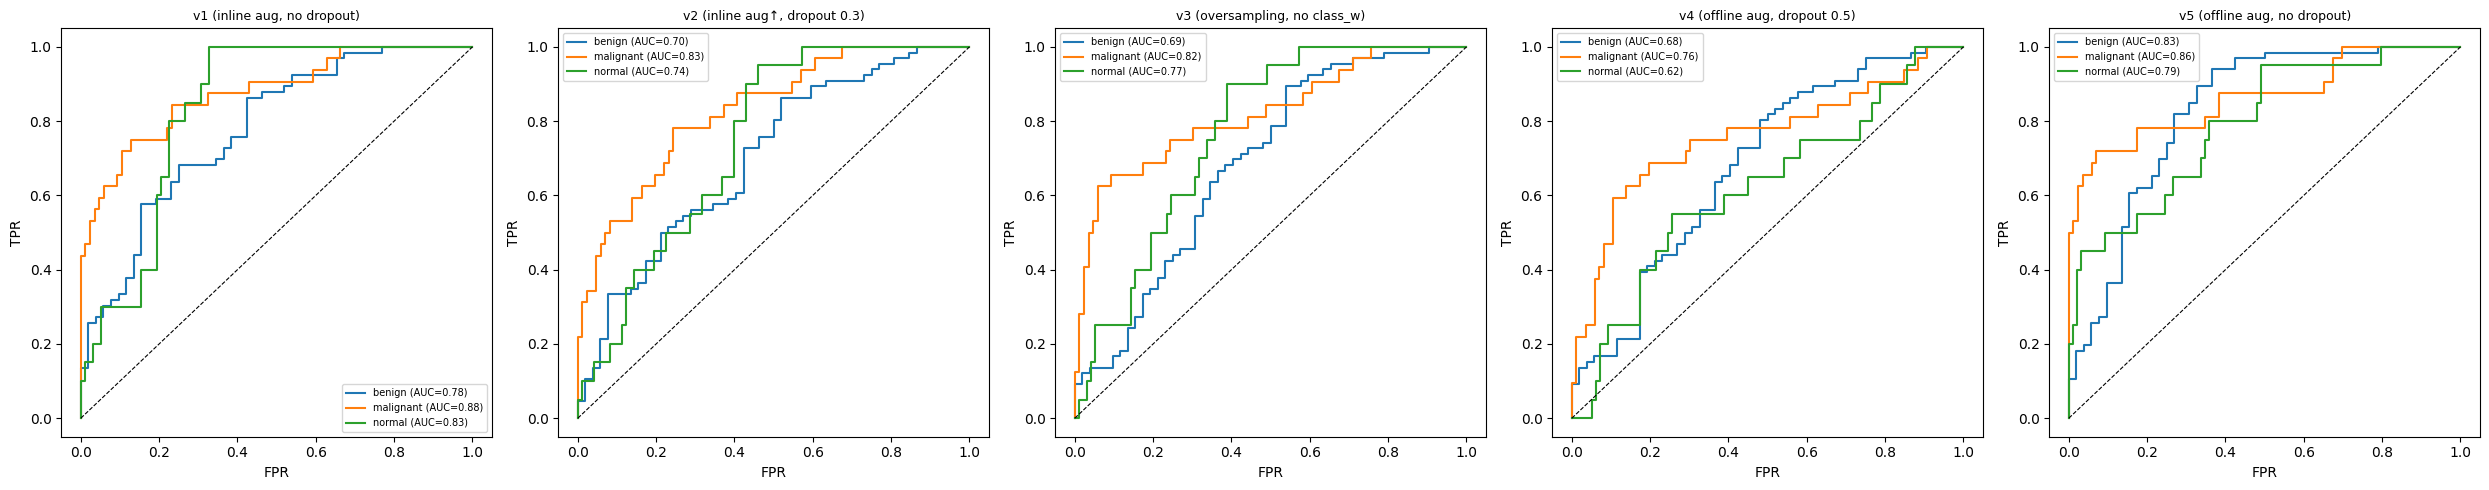

In [ ]:
from sklearn.metrics import roc_curve, auc

scratch_checkpoints = {
    'v1 (inline aug, no dropout)':     'cnn_scratch_best.keras',
    'v2 (inline aug↑, dropout 0.3)':   'cnn_scratch_v2_best.keras',
    'v3 (oversampling, no class_w)':   'cnn_scratch_v3_best.keras',
    'v4 (offline aug, dropout 0.5)':   'cnn_scratch_v4_best.keras',
    'v5 (offline aug, no dropout)':    'cnn_scratch_v5_best.keras',
}

scratch_models_dir = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/'

fig, axes = plt.subplots(1, len(scratch_checkpoints), figsize=(25, 5))

y_val_true_bin = np.eye(3)[y_val_true]

for ax, (label, fname) in zip(axes, scratch_checkpoints.items()):
    path = os.path.join(scratch_models_dir, fname)
    if not os.path.exists(path):
        ax.set_title(f"{label}\n(non trovato)")
        continue

    model = keras.models.load_model(path)
    y_pred_probs = model.predict(val_dataset, verbose=0)

    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_val_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# **BLOCK 3: TRANSFER LEARNING**

In [ ]:
busi_split_path = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/BUSI_split/'

#TRAIN DATASET = BASE SPLIT DATASET
train_dataset = keras.utils.image_dataset_from_directory(
    busi_split_path + 'train',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=True,
    seed=1
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 544 files belonging to 3 classes.
Classes: ['benign', 'malignant', 'normal']


In [ ]:
models_dir = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/fine_tuned/'
os.makedirs(models_dir, exist_ok=True)

In [ ]:
# VGG16

base_net = keras.applications.VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False, pooling='avg')
base_net.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = keras.applications.vgg16.preprocess_input(inputs)
x = base_net(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(3, activation='softmax')(x)
net_vgg16 = keras.Model(inputs, outputs)

net_vgg16.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

checkpoint_path = models_dir + 'tl_vgg16_best.keras'
history_path = models_dir + 'history_tl_vgg16.json'

checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
if os.path.exists(checkpoint_path):
    net_vgg16 = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    history = net_vgg16.fit(
        train_dataset,
        epochs=50,
        validation_data=val_dataset,
        class_weight=class_weight_dict,
        callbacks=[early_stop, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)


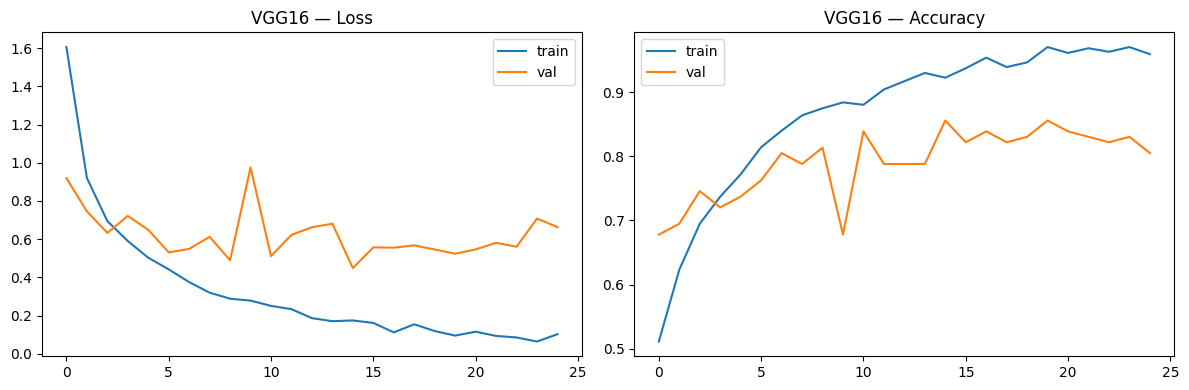

4/4 ━━━━━━━━━━━━━━━━━━━━ 86s 20s/step
              precision    recall  f1-score   support

      benign       0.88      0.91      0.90        66
   malignant       0.87      0.81      0.84        32
      normal       0.75      0.75      0.75        20

    accuracy                           0.86       118
   macro avg       0.83      0.82      0.83       118
weighted avg       0.86      0.86      0.86       118



In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_dict['loss']); plt.plot(history_dict['val_loss'])
plt.legend(['train', 'val']); plt.title('VGG16 — Loss')
plt.subplot(1,2,2)
plt.plot(history_dict['accuracy']); plt.plot(history_dict['val_accuracy'])
plt.legend(['train', 'val']); plt.title('VGG16 — Accuracy')
plt.tight_layout(); plt.show()

y_pred = np.argmax(net_vgg16.predict(val_dataset), axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_dataset])
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# EFFICIENT NET B0

base_net = keras.applications.EfficientNetB0(input_shape=(224,224,3), weights='imagenet', include_top=False, pooling='avg')
base_net.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = keras.applications.efficientnet.preprocess_input(inputs)
x = base_net(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(3, activation='softmax')(x)
net_eff = keras.Model(inputs, outputs)

net_eff.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

checkpoint_path = models_dir + 'tl_efficientnetb0_best.keras'
history_path = models_dir + 'history_tl_efficientnetb0.json'

checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
if os.path.exists(checkpoint_path):
    net_eff = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    history = net_eff.fit(
        train_dataset,
        epochs=50,
        validation_data=val_dataset,
        class_weight=class_weight_dict,
        callbacks=[early_stop, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)


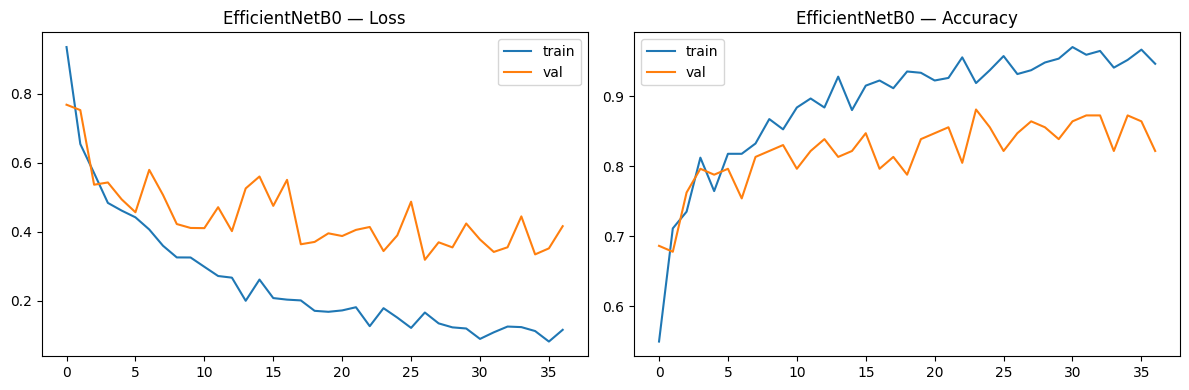

4/4 ━━━━━━━━━━━━━━━━━━━━ 85s 19s/step
              precision    recall  f1-score   support

      benign       0.95      0.83      0.89        66
   malignant       0.71      0.84      0.77        32
      normal       0.82      0.90      0.86        20

    accuracy                           0.85       118
   macro avg       0.83      0.86      0.84       118
weighted avg       0.86      0.85      0.85       118



In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_dict['loss']); plt.plot(history_dict['val_loss'])
plt.legend(['train', 'val']); plt.title('EfficientNetB0 — Loss')
plt.subplot(1,2,2)
plt.plot(history_dict['accuracy']); plt.plot(history_dict['val_accuracy'])
plt.legend(['train', 'val']); plt.title('EfficientNetB0 — Accuracy')
plt.tight_layout(); plt.show()

y_pred = np.argmax(net_eff.predict(val_dataset), axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_dataset])
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# DENSE NET 121
base_net = keras.applications.DenseNet121(input_shape=(224,224,3), weights='imagenet', include_top=False, pooling='avg')
base_net.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = keras.applications.densenet.preprocess_input(inputs)
x = base_net(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(3, activation='softmax')(x)
net_dense = keras.Model(inputs, outputs)

net_dense.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

checkpoint_path = models_dir + 'tl_densenet121_best.keras'
history_path = models_dir + 'history_tl_densenet121.json'

checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
if os.path.exists(checkpoint_path):
    net_dense = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    history = net_dense.fit(
        train_dataset,
        epochs=50,
        validation_data=val_dataset,
        class_weight=class_weight_dict,
        callbacks=[early_stop, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)


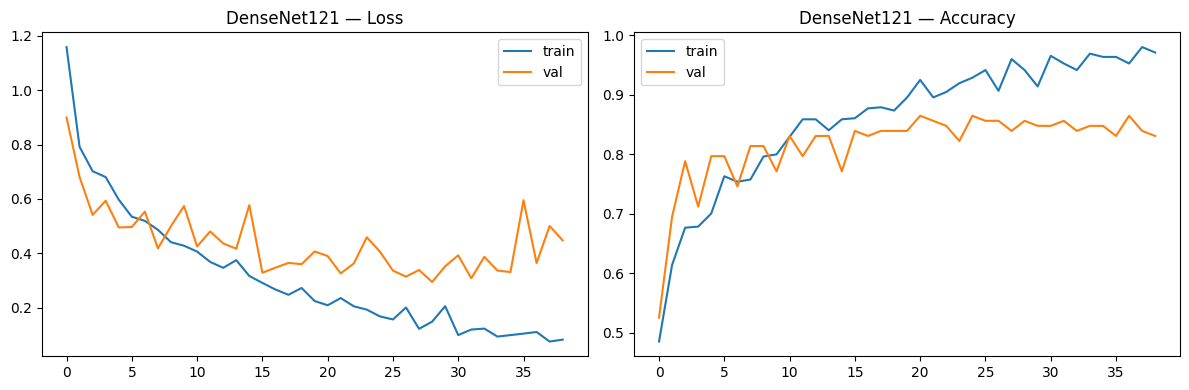

4/4 ━━━━━━━━━━━━━━━━━━━━ 47s 10s/step
              precision    recall  f1-score   support

      benign       0.90      0.86      0.88        66
   malignant       0.75      0.84      0.79        32
      normal       0.89      0.85      0.87        20

    accuracy                           0.86       118
   macro avg       0.85      0.85      0.85       118
weighted avg       0.86      0.86      0.86       118



In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_dict['loss']); plt.plot(history_dict['val_loss'])
plt.legend(['train', 'val']); plt.title('DenseNet121 — Loss')
plt.subplot(1,2,2)
plt.plot(history_dict['accuracy']); plt.plot(history_dict['val_accuracy'])
plt.legend(['train', 'val']); plt.title('DenseNet121 — Accuracy')
plt.tight_layout(); plt.show()

y_pred = np.argmax(net_dense.predict(val_dataset), axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_dataset])
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
# MOBILE NET V3 SMALL

base_net = keras.applications.MobileNetV3Small(input_shape=(224,224,3), weights='imagenet', include_top=False, pooling='avg')
base_net.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = keras.applications.mobilenet_v3.preprocess_input(inputs)
x = base_net(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(3, activation='softmax')(x)
net_mob = keras.Model(inputs, outputs)

net_mob.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

checkpoint_path = models_dir + 'tl_mobilenetv3_best.keras'
history_path = models_dir + 'history_tl_mobilenetv3.json'

checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
if os.path.exists(checkpoint_path):
    net_mob = keras.models.load_model(checkpoint_path)
    with open(history_path) as f:
        history_dict = json.load(f)
else:
    history = net_mob.fit(
        train_dataset,
        epochs=50,
        validation_data=val_dataset,
        class_weight=class_weight_dict,
        callbacks=[early_stop, checkpoint]
    )
    history_dict = history.history
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)


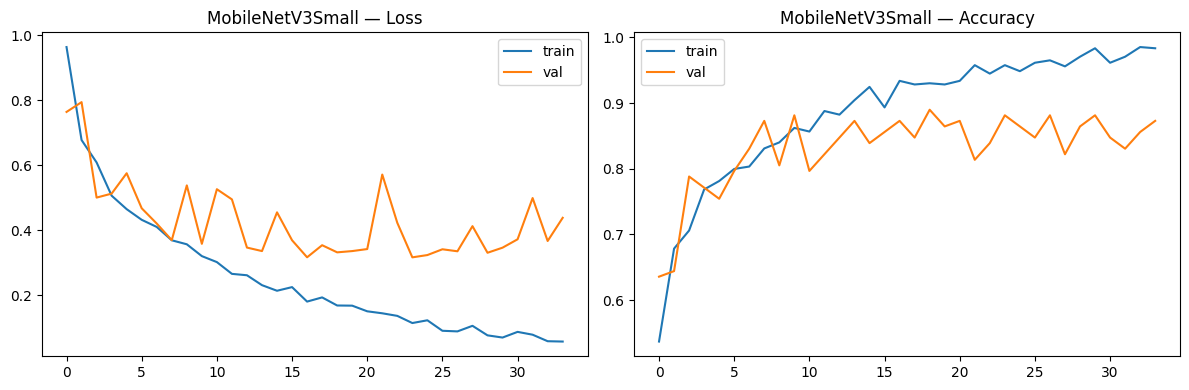

4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step
              precision    recall  f1-score   support

      benign       0.91      0.89      0.90        66
   malignant       0.90      0.84      0.87        32
      normal       0.78      0.90      0.84        20

    accuracy                           0.88       118
   macro avg       0.86      0.88      0.87       118
weighted avg       0.88      0.88      0.88       118



In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history_dict['loss']); plt.plot(history_dict['val_loss'])
plt.legend(['train', 'val']); plt.title('MobileNetV3Small — Loss')
plt.subplot(1,2,2)
plt.plot(history_dict['accuracy']); plt.plot(history_dict['val_accuracy'])
plt.legend(['train', 'val']); plt.title('MobileNetV3Small — Accuracy')
plt.tight_layout(); plt.show()

y_pred = np.argmax(net_mob.predict(val_dataset), axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_dataset])
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

models_dir = '/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/fine_tuned/'

checkpoints = {
    'VGG16':          'tl_vgg16_best.keras',
    'EfficientNetB0': 'tl_efficientnetb0_best.keras',
    'DenseNet121':    'tl_densenet121_best.keras',
    'MobileNetV3':    'tl_mobilenetv3_best.keras',
}

y_val_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_dataset])

print(f"{'Modello':<20} {'Accuracy':>10} {'F1 benign':>10} {'F1 malig':>10} {'F1 normal':>10} {'F1 macro':>10}")
print("-" * 65)

for label, fname in checkpoints.items():
    path = os.path.join(models_dir, fname)
    if not os.path.exists(path):
        print(f"{label:<20} {'(non trovato)':>10}")
        continue
    model = keras.models.load_model(path)
    y_pred = np.argmax(model.predict(val_dataset, verbose=0), axis=1)
    report = classification_report(y_val_true, y_pred, target_names=class_names, output_dict=True)
    print(f"{label:<20} {report['accuracy']:>10.4f} {report['benign']['f1-score']:>10.4f} {report['malignant']['f1-score']:>10.4f} {report['normal']['f1-score']:>10.4f} {report['macro avg']['f1-score']:>10.4f}")

Modello                Accuracy  F1 benign   F1 malig  F1 normal   F1 macro
-----------------------------------------------------------------
VGG16                    0.8559     0.8955     0.8387     0.7500     0.8281
EfficientNetB0           0.8475     0.8871     0.7714     0.8571     0.8386
DenseNet121              0.8559     0.8837     0.7941     0.8718     0.8499
MobileNetV3              0.8814     0.9008     0.8710     0.8372     0.8696


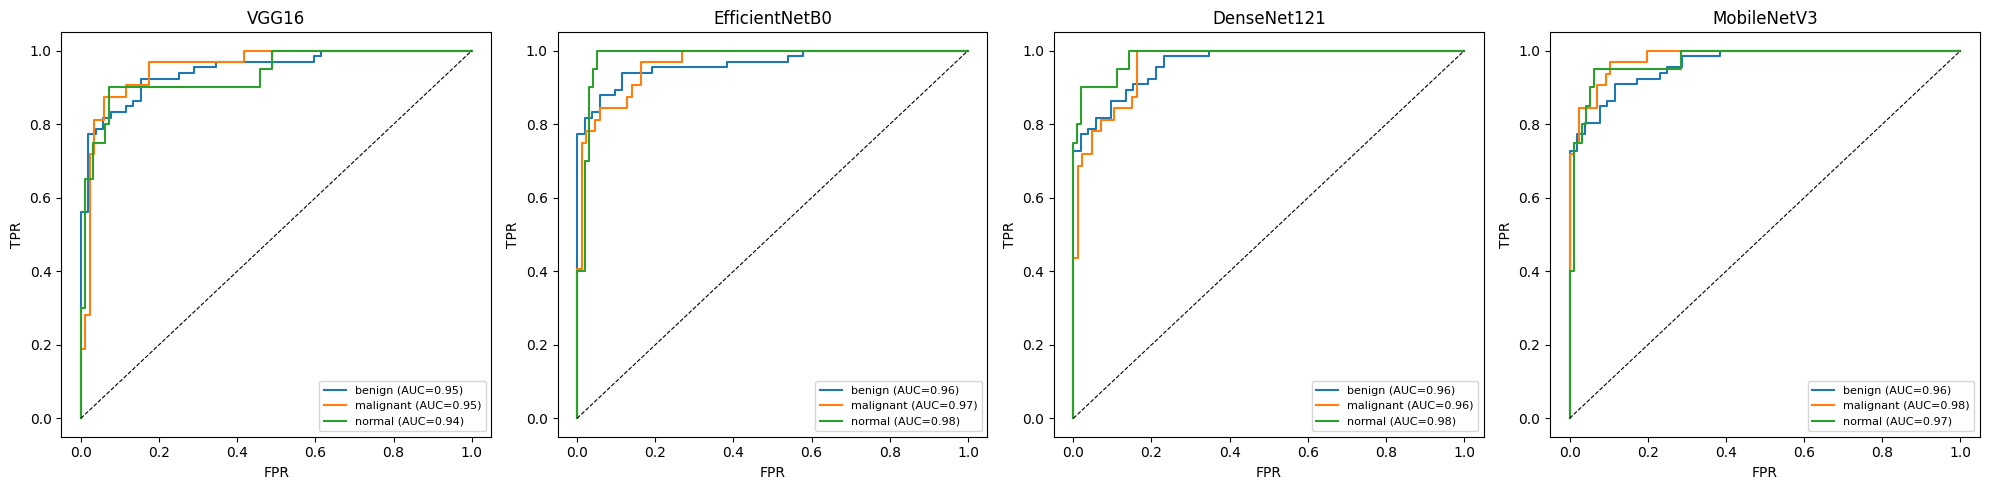

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(checkpoints), figsize=(20, 5))

for ax, (label, fname) in zip(axes, checkpoints.items()):
    path = os.path.join(models_dir, fname)
    if not os.path.exists(path):
        continue

    model = keras.models.load_model(path)
    y_pred_probs = model.predict(val_dataset, verbose=0)

    y_val_true_bin = np.eye(3)[y_val_true]  # one-hot

    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_val_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# **BLOCK 4: FINAL EVALUATION ON TEST SET**



In [ ]:
scratch_models_dir

'/content/gdrive/MyDrive/DEEP_LEARNING_PROJECT/models/from_scratch/'


CNN scratch v1
              precision    recall  f1-score   support

      benign       0.66      0.89      0.76        66
   malignant       0.75      0.47      0.58        32
      normal       0.62      0.25      0.36        20

    accuracy                           0.67       118
   macro avg       0.68      0.54      0.56       118
weighted avg       0.68      0.67      0.64       118



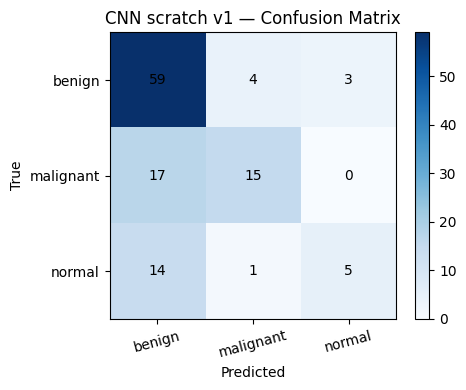

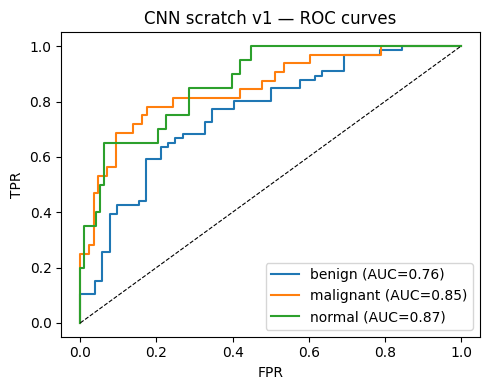


MobileNetV3Small
              precision    recall  f1-score   support

      benign       0.82      0.91      0.86        66
   malignant       0.78      0.66      0.71        32
      normal       0.89      0.80      0.84        20

    accuracy                           0.82       118
   macro avg       0.83      0.79      0.81       118
weighted avg       0.82      0.82      0.82       118



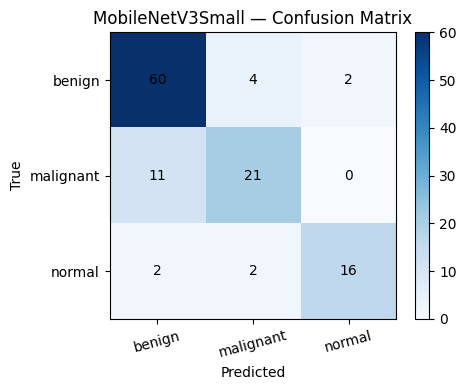

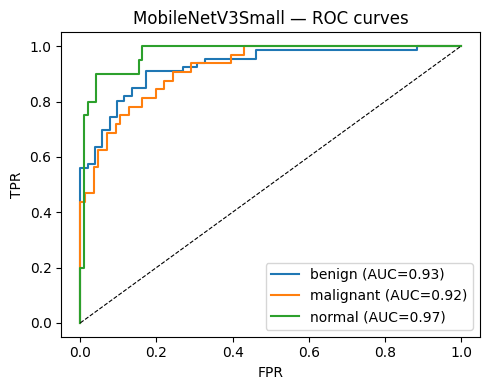

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

final_models = {
    'CNN scratch v1': scratch_models_dir + 'cnn_scratch_best.keras',
    'MobileNetV3Small': models_dir + 'tl_mobilenetv3_best.keras',
}

y_test_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_dataset])
y_test_true_bin = np.eye(3)[y_test_true]

for label, path in final_models.items():
    print(f"\n{'='*50}\n{label}\n{'='*50}")

    model = keras.models.load_model(path)
    y_pred_probs = model.predict(test_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(classification_report(y_test_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap=plt.cm.Blues)
    plt.title(f'{label} — Confusion Matrix')
    plt.xticks(range(3), class_names, rotation=15)
    plt.yticks(range(3), class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    for i in range(3):
        for j in range(3):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    plt.title(f'{label} — ROC curves')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.tight_layout()
    plt.show()
